In [2]:
### read in test scores data set  
testscores <- read.table("../../data/testscores.txt", header = TRUE)

In [31]:
head(testscores)

,x1,x2,x3,x4,x5,y1,y2,y3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,2,6,12,16,49,48,8
2,5,14,14,30,27,47,76,13
3,0,10,21,16,16,11,40,13
4,0,2,5,17,8,9,52,9
5,2,7,11,26,17,69,63,15
6,2,15,21,34,25,35,82,14


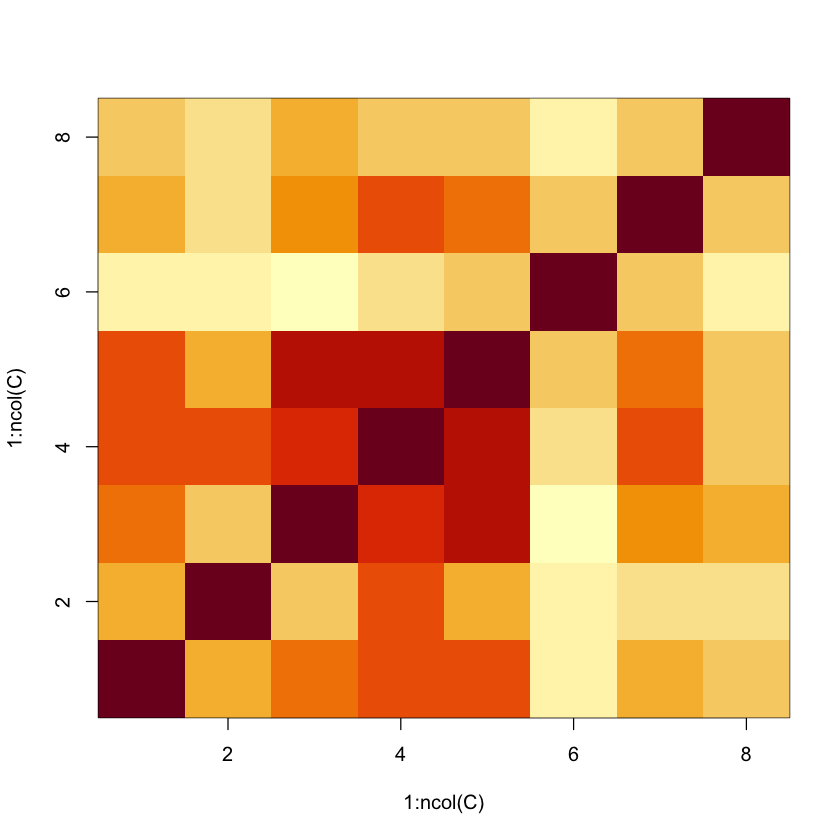

In [4]:
C <- cor(testscores)
# observe that the first block of variables (1 through 5) exhibit much stronger correlations.
image(1:ncol(C), 1:ncol(C), C)

In [32]:
C

,x1,x2,x3,x4,x5,y1,y2,y3
x1,1.0000000,0.4006592,0.53698253,0.6480688,0.6703912,0.18604792,0.4443651,0.3503596
x2,0.4006592,1.0000000,0.35234332,0.6478087,0.4251587,0.16089930,0.2681912,0.2385939
x3,0.5369825,0.3523433,1.00000000,0.7135691,0.7695358,0.06847411,0.4692140,0.4388055
x4,0.6480688,0.6478087,0.71356909,1.0000000,0.7951377,0.26171683,0.6720053,0.3390278
x5,0.6703912,0.4251587,0.76953580,0.7951377,1.0000000,0.33410374,0.5876337,0.3404206
y1,0.1860479,0.1608993,0.06847411,0.2617168,0.3341037,1.00000000,0.3703162,0.2114153
y2,0.4443651,0.2681912,0.46921397,0.6720053,0.5876337,0.37031617,1.0000000,0.3548077
y3,0.3503596,0.2385939,0.43880553,0.3390278,0.3404206,0.21141535,0.3548077,1.0000000


In [6]:
# separate X and Y variables 
p <- 5
q <- 3
X <- testscores[,paste("x", 1:p, sep = "")]
Y <- testscores[,paste("y", 1:q, sep = "")]

In [7]:
# compute CCA projections via the SVD
Sigma_X <- cov(X)
Sigma_XY  <- cov(X, Y)
Sigma_Y <- cov(Y)

eig_SigmaX <- eigen(Sigma_X)
eig_SigmaY <- eigen(Sigma_Y)

Sigma_X_invhalf <- eig_SigmaX$vectors %*% diag(1/sqrt(eig_SigmaX$values)) %*% t(eig_SigmaX$vectors)
Sigma_Y_invhalf <- eig_SigmaY$vectors %*% diag(1/sqrt(eig_SigmaY$values)) %*% t(eig_SigmaY$vectors)

M <- Sigma_X_invhalf %*% Sigma_XY %*% Sigma_Y_invhalf
svdM <- svd(M)
Utilde <- svdM$u
Vtilde <- svdM$v

# canonical directions
U <- Sigma_X_invhalf %*% Utilde
V <- Sigma_Y_invhalf %*% Vtilde

In [33]:
U[,1]

[1]  0.007150868  0.075658454  0.035321752 -0.157915470 -0.043556257

In [8]:
# canonical variates
Z_X <- as.matrix(X) %*% U
Z_Y <- as.matrix(Y) %*% V

zapsmall(cov(Z_X)) # identity
zapsmall(cov(Z_Y)) # identity
zapsmall(cov(Z_X, Z_Y))

1,0,0
0,1,0
0,0,1


1,0,0
0,1,0
0,0,1


0.7165259,0.0000000,0.0000000
0.0000000,0.4906209,0.0000000
0.0000000,0.0000000,0.2667778


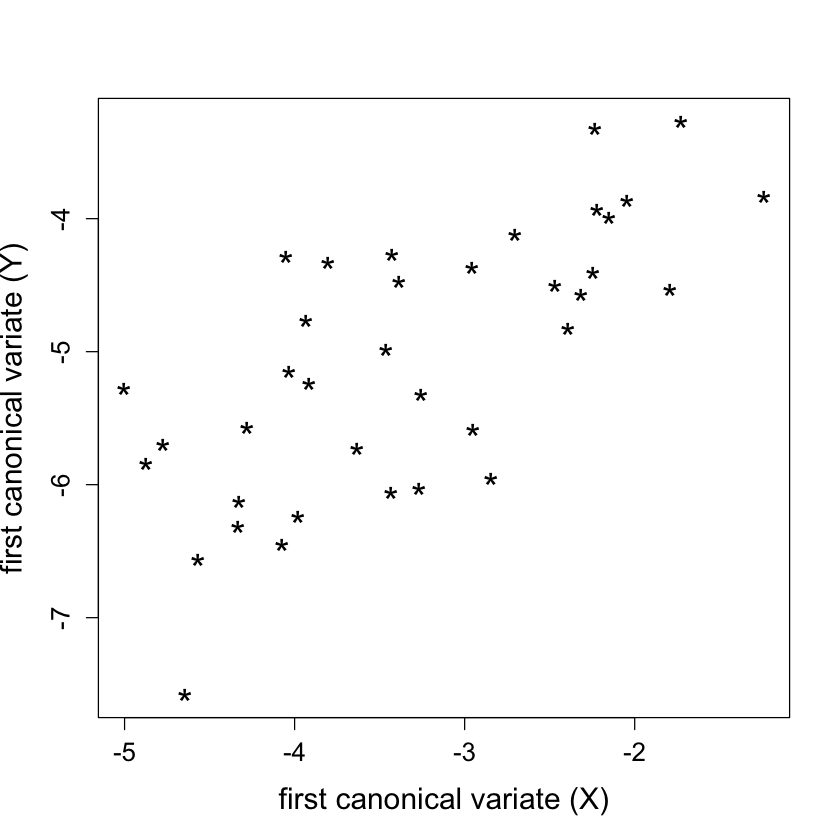

In [9]:
# scatterplot of the first pair of canonical variates
#pdf("../figs/cca.pdf")
plot(Z_X[,1], Z_Y[,1], pch = "*", cex = 2,
     xlab = "first canonical variate (X)",
     ylab = "first canonical variate (Y)", cex.lab = 1.5,
     cex.axis = 1.3)
#dev.off()

In [10]:
# getting the results directly without any matrix algebra:
cca_R <- cancor(X, Y)

# check for equality 1: canonical correlation coefficients
all.equal(cca_R$cor, diag(cov(Z_X, Z_Y)))

[1] TRUE

In [36]:
print(cca_R)

$cor
[1] 0.7165259 0.4906209 0.2667778

$xcoef
           [,1]         [,2]         [,3]         [,4]        [,5]
x1  0.001191811  0.026665177  0.016547842  0.067703727 -0.02539006
x2  0.012609742  0.007020674  0.029103980 -0.020218713 -0.02255255
x3  0.005886959  0.039693413 -0.001680101 -0.010045986  0.01143806
x4 -0.026319245 -0.009903135 -0.038171717 -0.001726236 -0.01191325
x5 -0.007259376 -0.030398519  0.033658214 -0.006118626  0.02346194

$ycoef
            [,1]         [,2]         [,3]
y1 -0.0005377254 -0.005529338  0.005967617
y2 -0.0127041313 -0.000278583 -0.008042547
y3 -0.0023553761  0.045941222  0.035072546

$xcenter
       x1        x2        x3        x4        x5 
 2.540541  6.918919 13.486486 22.378378 18.378378 

$ycenter
      y1       y2       y3 
31.27027 62.64865 13.24324 



In [30]:
n <- nrow(X)
#plot(as.matrix(X) %*% cca_R$xcoef[,1:3] * (-sqrt(n-1)),
#          as.matrix(X) %*% U)
#abline(0,1)

# own computations and R output are equal up to a sign and a scaling factor
                                        # sqrt(n-1)... took a while to figure this out since the R documentation does not make this clear.
all.equal(as.matrix(X) %*% cca_R$xcoef[,1:3] * (sqrt(n-1)), as.matrix(X) %*% U %*% diag(x = c(1, -1, 1), 3, 3))
all.equal(as.matrix(Y) %*% cca_R$ycoef[,1:3] * (sqrt(n-1)), as.matrix(Y) %*% V %*% diag(x = c(1, -1, 1), 3, 3))


# confirms the canonical correlation coefficients
cor(as.matrix(X) %*% cca_R$xcoef[,1:3],
    as.matrix(Y) %*% cca_R$ycoef)

[1] TRUE

[1] TRUE

7.165259e-01,1.341437e-16,1.032589e-16
3.163960e-16,4.906209e-01,2.907853e-17
1.829466e-16,-1.146236e-16,2.667778e-01
